# Markowitz Portfolio Optimization

## 1. Motivation

Portfolio selection depends on both individual asset risk and **covariance between assets**.
This note develops the risk–return trade-off through five small optimization experiments:
budget-only global minimum variance (GMV), a long-only constraint, a minimum expected return,
the efficient frontier, and preference-based selection with a risk-aversion parameter.

The inputs are **synthetic / illustrative and already annualized**. They isolate the
optimization problem; they are not historical estimates, market forecasts, or realized
investment performance. All experiments use the same three assets.

## 2. Mathematical Setup

For $n$ assets, let $w\in\mathbb{R}^n$ be portfolio weights,
$\mu\in\mathbb{R}^n$ expected returns, and $\Sigma\in\mathbb{R}^{n\times n}$ the
return covariance matrix. Full investment means $\mathbf{1}^{\top}w=1$.

$$
\mathbb{E}[R_p]=\mu^\top w,\qquad
\sigma_p^2=w^\top\Sigma w,\qquad
\sigma_p=\sqrt{w^\top\Sigma w}.
$$

The variance includes all pairwise interactions:

$$
w^\top\Sigma w
=\sum_i w_i^2\Sigma_{ii}+2\sum_{i<j}w_iw_j\Sigma_{ij}.
$$

Thus, asset volatilities alone do not determine portfolio risk. A valid covariance
matrix is symmetric and positive semidefinite, making the variance objective convex.
Our supplied matrix is positive definite, so its quadratic objective is strictly convex.
Returns and volatility are decimals: $0.08$ means $8\%$. Variance is in squared-return
units. No further annualization is applied.

The next cell loads the shared inputs from the Python module. Root detection is automatic
when this notebook is run from either the project root or the `notebooks/` directory.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents)
     if (path / "src" / "portfolio_optimization.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise RuntimeError("Open this notebook inside the project directory.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.portfolio_optimization import (
    PortfolioResult,
    analytical_gmv,
    example_data,
    generate_efficient_frontier,
    portfolio_return,
    portfolio_variance,
    portfolio_volatility,
    solve_gmv_cvxpy,
    solve_risk_aversion_portfolio,
    solve_target_return_portfolio,
    validate_inputs,
)
from run_analysis import (
    TARGET_RETURN,
    RISK_AVERSIONS,
    plot_efficient_frontier,
    plot_risk_aversion,
)

mu, Sigma, asset_names = example_data()
mu, Sigma = validate_inputs(mu, Sigma)
FIGURES = PROJECT_ROOT / "figures"
RESULTS = PROJECT_ROOT / "results"
pd.options.display.float_format = "{:.6f}".format

display(pd.DataFrame({
    "expected_return": mu,
    "volatility": np.sqrt(np.diag(Sigma)),
}, index=asset_names))
display(pd.DataFrame(Sigma, index=asset_names, columns=asset_names))
print("Covariance eigenvalues:", np.round(np.linalg.eigvalsh(Sigma), 8))

,expected_return,volatility
Asset A,0.080000,0.200000
Asset B,0.050000,0.100000
Asset C,0.120000,0.150000


,Asset A,Asset B,Asset C
Asset A,0.040000,0.006000,0.012000
Asset B,0.006000,0.010000,0.004000
Asset C,0.012000,0.004000,0.022500


## 3. Global Minimum Variance Portfolio

First allow short selling and impose only full investment:

$$
\min_w\;w^\top\Sigma w
\quad\text{subject to}\quad \mathbf{1}^\top w=1.
$$

With $L(w,\nu)=w^\top\Sigma w+\nu(\mathbf{1}^\top w-1)$,
stationarity gives $2\Sigma w+\nu\mathbf{1}=0$.
Combining this with the budget constraint yields

$$
w_{\mathrm{GMV}}
=\frac{\Sigma^{-1}\mathbf{1}}
       {\mathbf{1}^\top\Sigma^{-1}\mathbf{1}}.
$$

The formula requires invertible positive-definite $\Sigma$.
The implementation uses `np.linalg.solve` instead of explicitly computing an inverse.
CVXPY also handles singular positive-semidefinite inputs, for which this formula
does not apply and the optimum need not be unique.

“Unconstrained GMV” below means **budget-only**; it still has the full-investment constraint.

In [2]:
w_analytical = analytical_gmv(Sigma)
analytical = PortfolioResult(
    weights=w_analytical,
    expected_return=portfolio_return(w_analytical, mu),
    variance=portfolio_variance(w_analytical, Sigma),
    volatility=portfolio_volatility(w_analytical, Sigma),
    status="analytical",
)
gmv_unconstrained = solve_gmv_cvxpy(mu, Sigma, long_only=False)

np.testing.assert_allclose(
    w_analytical, gmv_unconstrained.weights, atol=1e-8, rtol=1e-7
)
display(pd.DataFrame([
    {"method": "Analytical", **analytical.to_record(asset_names)},
    {"method": "CVXPY", **gmv_unconstrained.to_record(asset_names)},
]).set_index("method"))
print(
    "Maximum absolute weight difference:",
    f"{np.max(np.abs(w_analytical - gmv_unconstrained.weights)):.2e}",
)

,weight_Asset_A,weight_Asset_B,weight_Asset_C,expected_return,variance,volatility,status
method,,,,,,,
Analytical,0.033037,0.738247,0.228717,0.067001,0.008496,0.092171,analytical
CVXPY,0.033037,0.738247,0.228717,0.067001,0.008496,0.092171,optimal


## 4. Long-only Constraint

Now prohibit negative holdings:

$$
\min_w\;w^\top\Sigma w
\quad\text{subject to}\quad
\mathbf{1}^\top w=1,\quad w\geq 0.
$$

Adding constraints shrinks the feasible set, so the minimum variance cannot decrease.
It need not increase: if the original GMV weights are all positive, the new inequalities
are inactive. If an original weight is exactly zero, that constraint is active even
though the optimizer may remain unchanged.

For a short KKT interpretation, write
$L(w,\nu,\alpha)=w^\top\Sigma w+\nu(\mathbf{1}^\top w-1)-\alpha^\top w$.

| Condition | Meaning in this problem |
|---|---|
| Stationarity | $2\Sigma w+\nu\mathbf{1}-\alpha=0$ |
| Primal feasibility | $\mathbf{1}^\top w=1,\;w\geq0$ |
| Dual feasibility | $\alpha\geq0$; $\nu$ is unrestricted |
| Complementary slackness | $\alpha_iw_i=0$ for each asset |

If $w_i>0$, complementary slackness forces $\alpha_i=0$.
Only a constraint on the boundary ($w_i=0$) **can** have a nonzero multiplier;
a boundary constraint can also have a zero multiplier. This condition does not force
the portfolio to a boundary. It connects the inequality multipliers to the constraints
that actually restrict the solution.

These convex conditions certify global optimality. Strictly positive equal weights
provide a strictly feasible point for the long-only inequalities, so Slater's condition
holds here. The numerical residuals below make the interpretation observable.

In [3]:
gmv_long_only = solve_gmv_cvxpy(mu, Sigma, long_only=True)
np.testing.assert_allclose(
    gmv_unconstrained.weights, gmv_long_only.weights, atol=2e-7, rtol=0
)
display(pd.DataFrame([
    {"model": "Budget-only", **gmv_unconstrained.to_record(asset_names)},
    {"model": "Long-only", **gmv_long_only.to_record(asset_names)},
]).set_index("model"))

stationarity = (
    2 * Sigma @ gmv_long_only.weights
    + gmv_long_only.budget_dual
    - gmv_long_only.nonneg_duals
)
kkt_residuals = pd.Series({
    "budget residual": abs(gmv_long_only.weights.sum() - 1),
    "stationarity infinity norm": np.max(np.abs(stationarity)),
    "dual nonnegativity violation": max(0, -gmv_long_only.nonneg_duals.min()),
    "complementary slackness residual": np.max(np.abs(
        gmv_long_only.weights * gmv_long_only.nonneg_duals
    )),
}, name="absolute residual")
display(kkt_residuals.to_frame().style.format("{:.2e}"))
print("All three GMV weights are strictly positive:",
      bool(np.all(gmv_long_only.weights > 1e-7)))

,weight_Asset_A,weight_Asset_B,weight_Asset_C,expected_return,variance,volatility,status
model,,,,,,,
Budget-only,0.033037,0.738247,0.228717,0.067001,0.008496,0.092171,optimal
Long-only,0.033037,0.738246,0.228717,0.067001,0.008496,0.092171,optimal


,absolute residual
budget residual,0.00e+00
stationarity infinity norm,1.11e-14
dual nonnegativity violation,0.00e+00
complementary slackness residual,2.61e-11


## 5. Minimum Expected Return Constraint

Minimum risk alone may provide too little expected return. A return floor makes
the trade-off explicit:

$$
\begin{aligned}
\min_w\quad & w^\top\Sigma w\\
\text{subject to}\quad &
\mathbf{1}^\top w=1,\quad w\geq0,\quad
\mu^\top w\geq R_{\mathrm{target}}.
\end{aligned}
$$

Use $R_{\mathrm{target}}=0.08$. This is an **expected** return requirement, not a
guaranteed realized return. Under full investment and long-only weights, expected return
is a weighted average of asset means, so a floor above $\max_i\mu_i=0.12$ is infeasible.

A constraint is reported as binding when the absolute return gap is at most $10^{-7}$
in decimal-return units. A second, lower target illustrates slackness.

In [4]:
target_portfolio = solve_target_return_portfolio(mu, Sigma, TARGET_RETURN)
low_target_portfolio = solve_target_return_portfolio(mu, Sigma, 0.05)
display(pd.DataFrame([
    {
        "return_floor": result.target_return,
        **result.to_record(asset_names),
        "return_gap": result.expected_return - result.target_return,
        "binding": result.return_constraint_binding,
    }
    for result in [low_target_portfolio, target_portfolio]
]).set_index("return_floor"))
assert target_portfolio.expected_return >= TARGET_RETURN - 1e-8
assert target_portfolio.return_constraint_binding
assert not low_target_portfolio.return_constraint_binding
np.testing.assert_allclose(
    low_target_portfolio.weights, gmv_long_only.weights, atol=2e-7, rtol=0
)

,weight_Asset_A,weight_Asset_B,weight_Asset_C,expected_return,variance,volatility,status,return_gap,binding
return_floor,,,,,,,,,
0.050000,0.033037,0.738247,0.228717,0.067001,0.008496,0.092171,optimal,0.017001,False
0.080000,0.024390,0.557491,0.418118,0.080000,0.009338,0.096633,optimal,0.000000,True


The 8% floor exceeds the GMV return and therefore binds for these inputs.
The 5% floor is already satisfied by GMV and leaves its solution unchanged.
For the target-return problem, stationarity additionally contains $-\beta\mu$,
where $\beta\geq0$ is the multiplier of $R_{\mathrm{target}}-\mu^\top w\leq0$.
Complementary slackness becomes $\beta(R_{\mathrm{target}}-\mu^\top w)=0$.

## 6. Efficient Frontier

Solve the long-only target-return problem at **80 targets**, from the long-only GMV
return to the feasible maximum of 12%, including both endpoints.
Starting below GMV would repeatedly return the same portfolio and would not add
new efficient portfolios. The figure uses achieved return, rather than the requested
return floor, on its vertical axis.

A portfolio is **dominated** if another feasible portfolio has no higher risk and
no lower expected return, with at least one strict improvement. An **efficient**
portfolio is not dominated. The frontier gives the minimum risk needed for a return
target, equivalently the highest return obtainable under the associated risk budget.

The sampler requires positive-definite covariance, as supplied here. With singular covariance, nonunique GMV weights would need an additional return tie-break to avoid including dominated points.

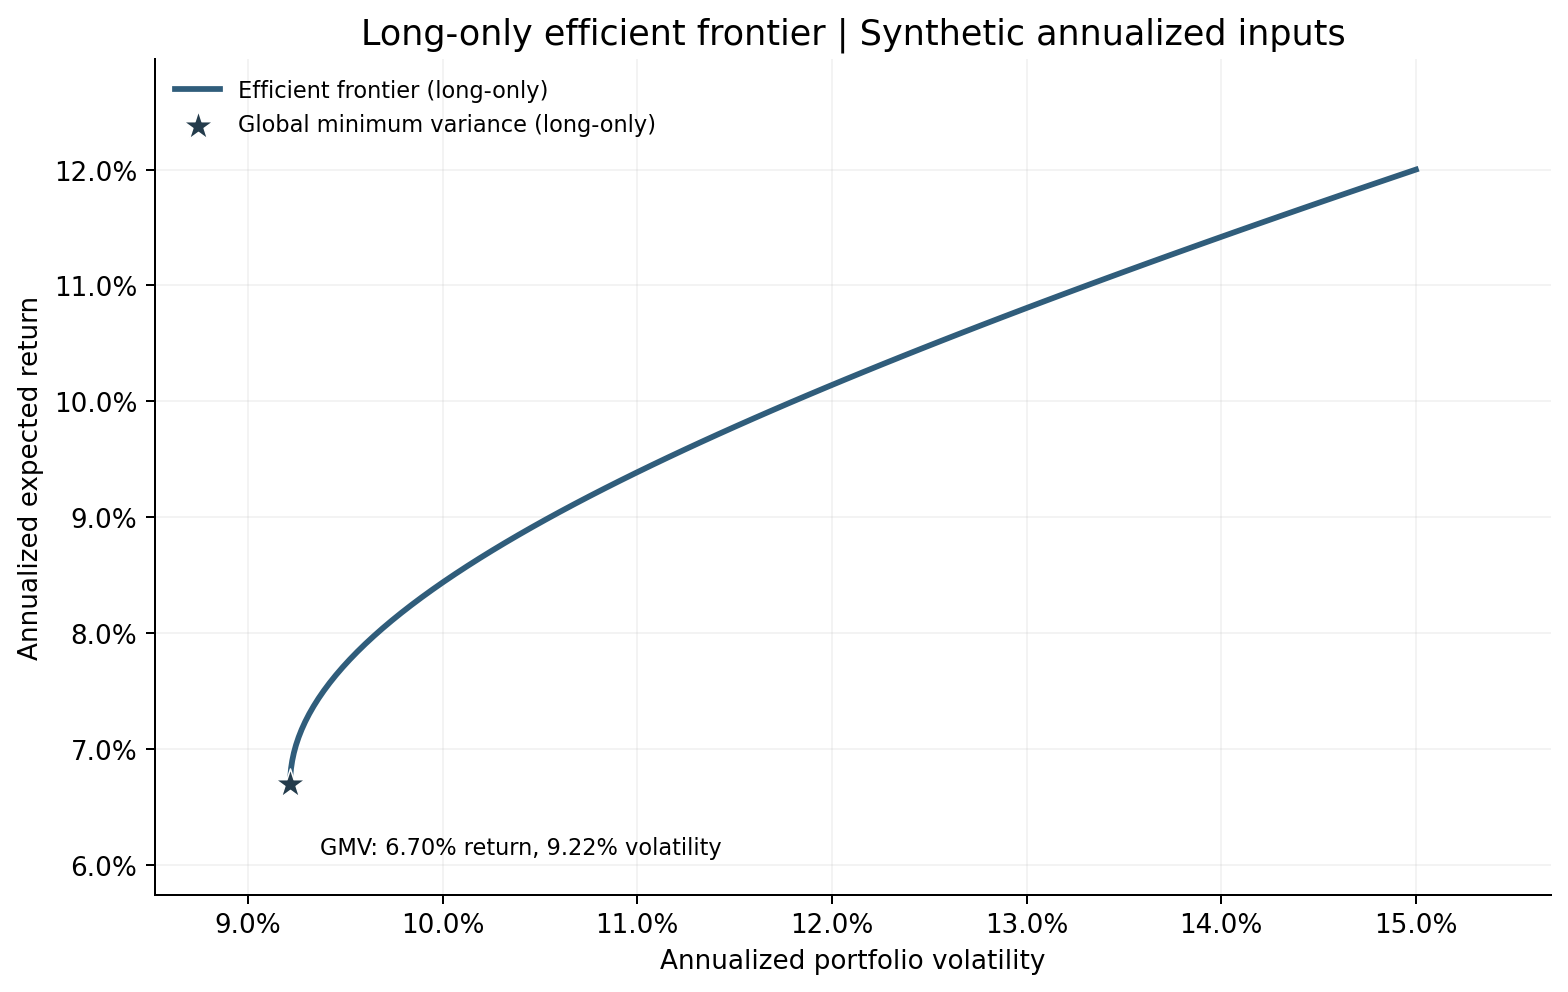

In [5]:
frontier = generate_efficient_frontier(
    mu, Sigma, n_points=80, asset_names=asset_names
)
weight_columns = ["weight_Asset_A", "weight_Asset_B", "weight_Asset_C"]
np.testing.assert_allclose(
    frontier[weight_columns].sum(axis=1), 1, atol=1e-8, rtol=0
)
assert (frontier[weight_columns].to_numpy() >= -1e-8).all()
assert (
    frontier["expected_return"] >= frontier["target_return"] - 1e-8
).all()
assert (np.diff(frontier["variance"]) >= -1e-8).all()
frontier_path = plot_efficient_frontier(
    frontier, gmv_long_only, FIGURES / "efficient_frontier.png"
)
display(Image(filename=str(frontier_path), width=860))
print(f"{len(frontier)} feasible frontier portfolios, including GMV and the maximum-return endpoint.")

The frontier summarizes the opportunities available **under the assumed inputs and
constraints**; investor preferences determine which point to choose.
Portfolios below it sacrifice return without reducing risk enough to be efficient.

The individual Asset A is dominated by Asset C as a standalone holding (8% versus 12%
expected return, 20% versus 15% volatility). Yet A can still receive a positive portfolio
weight: its covariance with other holdings affects the total risk. Standalone asset
rankings do not replace portfolio optimization.

## 7. Risk Aversion

Choose a portfolio directly from a preference parameter:

$$
\begin{aligned}
\max_w\quad & \mu^\top w-\lambda w^\top\Sigma w\\
\text{subject to}\quad &\mathbf{1}^\top w=1,\quad w\geq0,\quad\lambda>0.
\end{aligned}
$$

Larger $\lambda$ penalizes variance more strongly; smaller $\lambda$ places relatively
more emphasis on expected return. Here $\lambda$ is a chosen preference parameter,
distinct from the KKT multipliers $\alpha,\beta,\nu$. There is **no factor of $1/2$**
in the penalty and **no 8% return floor** in this separate experiment.
Lambda values depend on the units and horizon; these calculations use annualized
decimal returns and variance.

For two values $\lambda_2>\lambda_1$, the two optimality inequalities imply
$V_2\leq V_1$ and then $\mu^\top w_2\leq\mu^\top w_1$.
These relationships are weak: several lambda values can choose the same corner
portfolio. With positive lambda, a dominated portfolio cannot maximize this objective.
As lambda grows, the solutions approach the unique GMV portfolio for our inputs.

In [6]:
lambda_sensitivity = pd.DataFrame([
    {
        "lambda": value,
        **solve_risk_aversion_portfolio(mu, Sigma, value).to_record(asset_names),
    }
    for value in RISK_AVERSIONS
])
display(lambda_sensitivity.set_index("lambda"))
assert (np.diff(lambda_sensitivity["variance"]) <= 1e-8).all()
assert (np.diff(lambda_sensitivity["expected_return"]) <= 1e-8).all()

,weight_Asset_A,weight_Asset_B,weight_Asset_C,expected_return,variance,volatility,status
lambda,,,,,,,
0.100000,0.000000,-0.000000,1.000000,0.120000,0.022500,0.150000,optimal
0.500000,0.000000,0.000000,1.000000,0.120000,0.022500,0.150000,optimal
1.000000,0.000000,0.000000,1.000000,0.120000,0.022500,0.150000,optimal
2.000000,0.000000,0.040816,0.959184,0.117143,0.021031,0.145019,optimal
5.000000,0.019695,0.459339,0.520966,0.087058,0.010501,0.102476,optimal
10.000000,0.026366,0.598793,0.374841,0.077030,0.008997,0.094852,optimal
20.000000,0.029701,0.668520,0.301779,0.072016,0.008621,0.092849,optimal


The three smallest lambda values select essentially 100% Asset C, so their chart
labels are grouped at one point. Larger lambda values move toward GMV along the
frontier. Raw solver weights are retained: tiny negative values within $10^{-8}$
can be floating-point residuals. They are not clipped or renormalized.

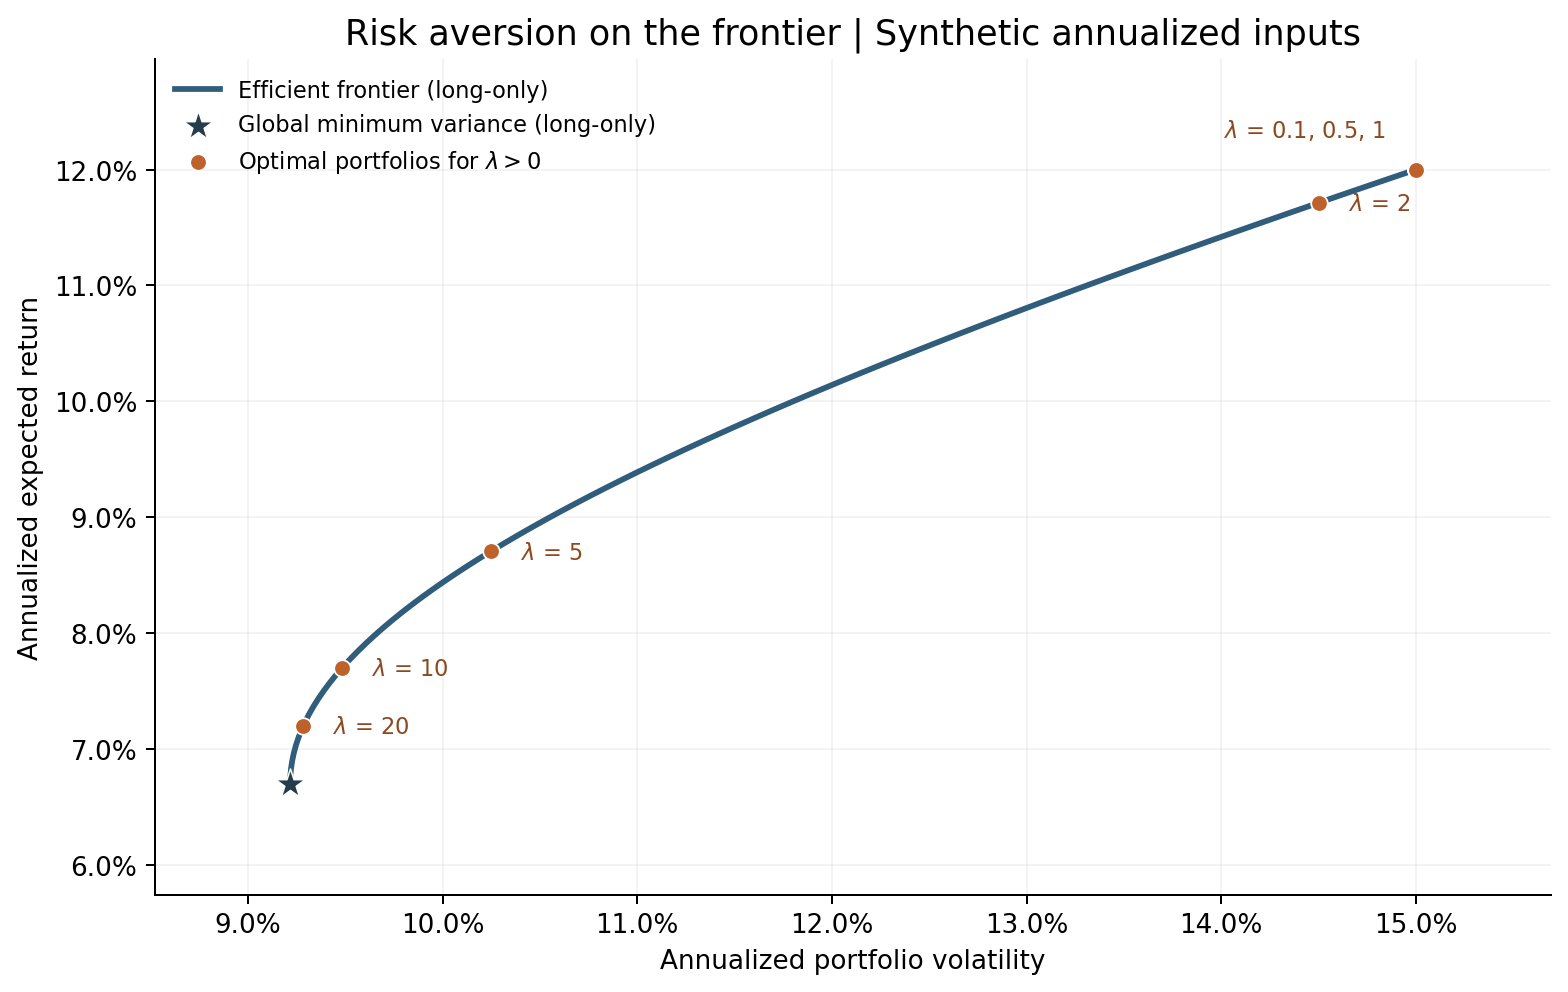

In [7]:
aversion_path = plot_risk_aversion(
    frontier, gmv_long_only, lambda_sensitivity,
    FIGURES / "risk_aversion_on_frontier.png",
)
display(Image(filename=str(aversion_path), width=860))

summary_rows = []
for label, result in [
    ("GMV (analytical)", analytical),
    ("GMV (CVXPY, shorting allowed)", gmv_unconstrained),
    ("GMV (CVXPY, long-only)", gmv_long_only),
    ("Target return >= 8% (long-only)", target_portfolio),
]:
    summary_rows.append({
        "portfolio": label,
        **result.to_record(asset_names),
        "target_return": result.target_return,
        "return_constraint_binding": result.return_constraint_binding,
    })
portfolio_summary = pd.DataFrame(summary_rows)
RESULTS.mkdir(parents=True, exist_ok=True)
portfolio_summary.to_csv(
    RESULTS / "portfolio_summary.csv", index=False, float_format="%.12g"
)
lambda_sensitivity.to_csv(
    RESULTS / "lambda_sensitivity.csv", index=False, float_format="%.12g"
)
print("Saved the two result tables and the two figures.")

## 8. Key Findings

In [8]:
display(Markdown(f'''
- **Covariance determines diversification benefits.** Risk depends on the entire
  covariance matrix, not only its diagonal.
- **Constraints shrink the feasible set.** They cannot improve the minimum
  variance. Here the short-sale restrictions are inactive: GMV holds positive
  weights in every asset, with {gmv_long_only.expected_return:.4%} expected return
  and {gmv_long_only.volatility:.4%} volatility.
- **Minimum-return constraints create an explicit trade-off.** The 8% floor binds
  and raises volatility to {target_portfolio.volatility:.4%}; the 5% floor is slack.
- **The efficient frontier summarizes optimal portfolios.** Its {len(frontier)}
  sampled points begin at long-only GMV and end at the 12% maximum-return portfolio.
- **Lambda provides a preference-based selection rule.** Increasing it weakly
  lowers both variance and expected return. Repeated corner solutions are valid.
'''))


- **Covariance determines diversification benefits.** Risk depends on the entire
  covariance matrix, not only its diagonal.
- **Constraints shrink the feasible set.** They cannot improve the minimum
  variance. Here the short-sale restrictions are inactive: GMV holds positive
  weights in every asset, with 6.7001% expected return
  and 9.2171% volatility.
- **Minimum-return constraints create an explicit trade-off.** The 8% floor binds
  and raises volatility to 9.6633%; the 5% floor is slack.
- **The efficient frontier summarizes optimal portfolios.** Its 80
  sampled points begin at long-only GMV and end at the 12% maximum-return portfolio.
- **Lambda provides a preference-based selection rule.** Increasing it weakly
  lowers both variance and expected return. Repeated corner solutions are valid.


## 9. Limitations

- Expected returns and covariance are assumed known and fixed.
- The inputs are synthetic, with no estimation error or parameter uncertainty modeled.
- There are no transaction costs or dynamic rebalancing.
- The model describes one allocation decision; it does not measure realized performance.
- Numerical solutions have finite precision; feasibility tolerance is $10^{-8}$.

The module checks optimizer status before reading weights and rejects infeasible,
unbounded, or insufficiently accurate solves. See the compact regression tests for
KKT residuals, analytical comparisons, a hand-solved two-asset case, and failure paths.

## 10. Future Work

- Real ETF data
- Rolling out-of-sample backtesting
- Transaction costs
- CVaR
- Robust optimization

These extensions are not implemented.

Implementation references:
[CVXPY quadratic programming](https://www.cvxpy.org/examples/basic/quadratic_program.html)
and [solver documentation](https://www.cvxpy.org/tutorial/solvers/index.html).